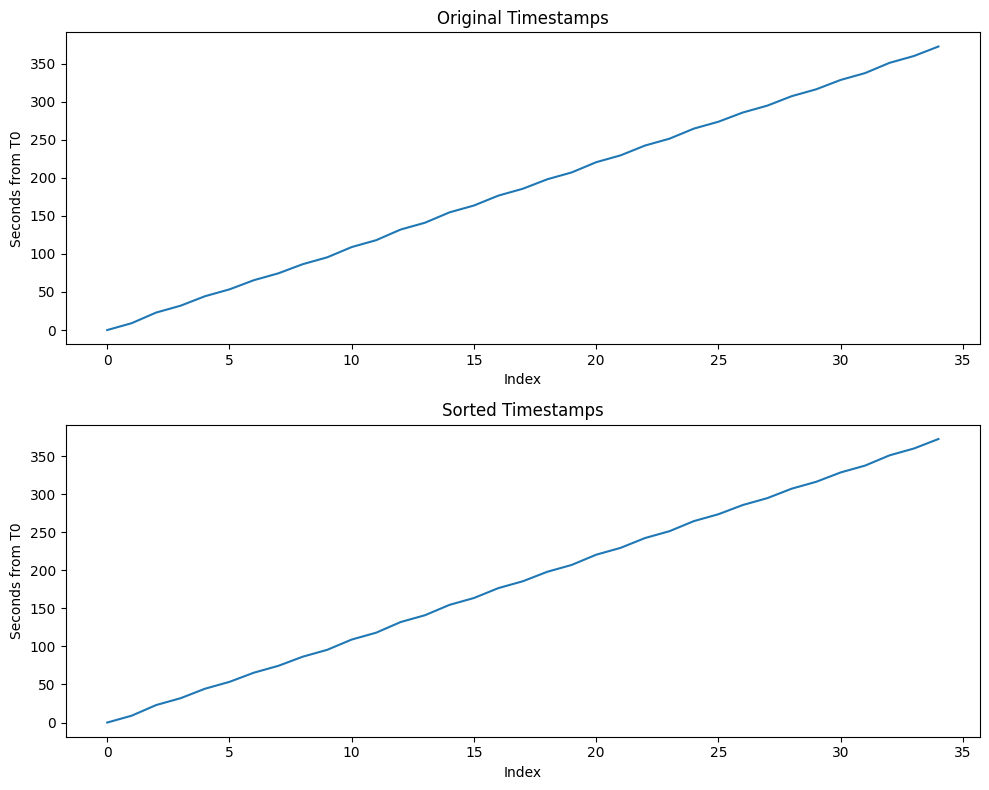

Fixed stop values in the TSV file


In [1]:
##################################
# Extract Psychotria task events #
##################################

from pathlib import Path
import pandas as pd
from datetime import datetime
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

base_path = Path('/Users/clairenastaskin/data/2025-05-07/sub-Forest001_ses-20250507_task-face_run-001')  
# Extract psychotria time events
task_path = list(base_path.glob('*events.tsv'))[0]
task_tsv_file = pd.read_csv(task_path, sep='\t')

# Convert timestamp column to datetime using ISO8601 format
task_tsv_file['timestamp'] = pd.to_datetime(task_tsv_file['timestamp'], format='ISO8601')
old_time_stamps_from_t0 = [(t - task_tsv_file['timestamp'].iloc[0]).total_seconds() for t in task_tsv_file['timestamp']]

# New task: Sort the dataframe by timestamp in chronological order
new_task_tsv_file = task_tsv_file.sort_values('timestamp')
new_task_tsv_file = new_task_tsv_file.reset_index(drop=True) # Reset the index after sorting
new_time_stamps_from_t0 = [(t - new_task_tsv_file['timestamp'].iloc[0]).total_seconds() for t in new_task_tsv_file['timestamp']]

# plot the two time series
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(old_time_stamps_from_t0)
ax[0].set_title('Original Timestamps')
ax[0].set_xlabel('Index')
ax[0].set_ylabel('Seconds from T0')
ax[1].plot(new_time_stamps_from_t0)
ax[1].set_title('Sorted Timestamps') 
ax[1].set_xlabel('Index')
ax[1].set_ylabel('Seconds from T0')
plt.tight_layout()
plt.show()

# Iterate through rows and fix stop values
for i in range(len(new_task_tsv_file)):
    if new_task_tsv_file.iloc[i]['start'] == True:
        # Check if previous row exists and has stop=True
        if i > 0 and new_task_tsv_file.iloc[i-1]['stop'] != True:
            # Set current row's stop to True
            new_task_tsv_file.at[i-1, 'stop'] = True
    
new_task_tsv_file.at[len(new_task_tsv_file)-1, 'stop'] = True
new_task_tsv_file.at[0, 'start'] = True

# Save the modified dataframe back to TSV
new_task_path = str(task_path).replace('events.tsv', 'events_new.tsv')
new_task_tsv_file.to_csv(new_task_path, sep='\t', index=False)
print("Fixed stop values in the TSV file")
